<a href="https://colab.research.google.com/github/Erencode27/DeepLearning/blob/main/02_naural_network_classification_With_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

from typing import BinaryIO
# Introduction to neural network classification with TensorFlow

In this notebook we're going to learn how to write neural networks for classification
A classification is  where you try to classifiy something as one thing or another.

A few types of classification problems:
* Binary classification
* Multiclass classification
* Multilabel classification


In [ ]:
## Creating data to view and fit

In [ ]:
from sklearn.datasets import make_circles
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
tf.__version__

# Make 1000 examples
n_samples = 1000

# Create circles
X,y =make_circles(n_samples,noise=0.03,random_state=42)

In [ ]:
# Check out the features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
# Check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

Our data is a little hard to understand right now... let's visualize it!

In [ ]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:,0],"X1":X[:,1],"label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


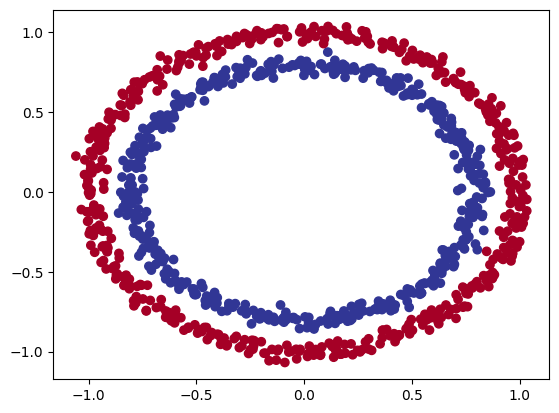

In [ ]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)


# Input and Output Shapes


In [ ]:
# Check the shapes of our features and labels
X.shape,y.shape

((1000, 2), (1000,))

In [ ]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [ ]:
#How many samples we're working
len(X), len(y)

(1000, 1000)

In [ ]:
# View the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

## Steps in Modelling


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
tf.random.set_seed(42)

# 1. Create a model (specified to your problem) by using the Sequential API


model  = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(100,activation ="relu"),
    tf.keras.layers.Dense(1,activation ="sigmoid")
])

# 2. Compile the model
model.compile(loss= tf.keras.losses.BinaryCrossentropy,
              optimizer = tf.keras.optimizers.Adam(),
              metrics = ["accuracy"])

# 3. Fit the model

model.fit(X,tf.expand_dims(y,axis=-1),epochs=100,verbose=0)

In [ ]:
# 4. Evaluate the model
model.evaluate(X,y)
tf.__version__

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.1092


'2.19.0'

In [ ]:
tf.random.set_seed(42)
# 1. Create a model with Sequential API

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)])
# 2. Compile the model

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy,
                optimizer = tf.keras.optimizers.SGD(),
                metrics=["Accuracy"])

# 3. Fit the model

model_2.fit(X,y,epochs=5,verbose=0)

In [ ]:
# Let's try and improve our model by training for longer..

# 1. Create a model by using Sequential API
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model

model_3.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.SGD(),
                metrics= ["Accuracy"])

# Fit the model
model_3.fit(X,y,epochs= 200,verbose=0)


In [ ]:
model_3.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.4852 - loss: 0.6927


[0.6932879686355591, 0.4729999899864197]

In [ ]:
circles["label"].value_counts()

,count
label,
1,500
0,500


# Improving Our Model
Let's look into our bag of tricks to see how we can improve our model.

1. Create a model- adding more layers, increasing hidden units
2. Compile a model- choosing a different optimization function
3. Fitting the model - traininig for longer with more epochs.



To visualize our model's predictions, let's create a function `plot_decision_boundary`, this function will:
* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make predictions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falls)


In [ ]:
import numpy as np

def plot_decision_boundary(model,X,y):
  """
  Plots the decision boundary created by a model predicting on X
  This function was inspired by two resources:
  1. https://cs231n.github.io/neural-networks-case-study/
  2. https://github.com/GokuMohandas?tab=repositories
   """
  #Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:,0].min() -0.1, X[:,0].max()+ 0.1
  y_min, y_max = X[:,1].min() -0.1, X[:,1].max()+ 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max,100),
           np.linspace(y_min, y_max,100))

  # Create x value (we're going to make predictions on these)
  X_in =np.c_[xx.ravel(),yy.ravel()] # stack 2D arrays together

  # Make predictions
  y_pred = model.predict(X_in)

  # Check for multi-class
  if len(y_pred[0])> 1:
    print("doing multiclass classification")
    # We have to reshape our prediction to get them ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx,yy,y_pred,cmap=plt.cm.RdYlBu,alpha=0.7)
  plt.scatter(X[:,0],X[:,1],c=y, s=40,cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(),xx.max())
  plt.ylim(yy.min(),yy.max())

"""
x_min, x_max = X[:, 0].min() -0.1, X[:, 0].max()+ 0.1
y_min, y_max = X[:, 1].min() -0.1, X[:, 1].max()+ 0.1

x_min,x_max,y_min,y_max
----
xx, yy = np.meshgrid(np.linspace(x_min, x_max,100),
           np.linspace(y_min, y_max,100))
X_in =np.c_[xx.ravel(),yy.ravel()] # stack 2D arrays together
-----
  # Make predictions
y_pred = model.predict(X_in)
y_pred[0]
-----
len(y_pred[0])
----
# Check for multi-class
if len(y_pred[0])> 1:
    print("doing multiclass classification")
    # We have to reshape our prediction to get them ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
    y_pred.shape
     """

'\nx_min, x_max = X[:, 0].min() -0.1, X[:, 0].max()+ 0.1\ny_min, y_max = X[:, 1].min() -0.1, X[:, 1].max()+ 0.1\n\nx_min,x_max,y_min,y_max\n----\nxx, yy = np.meshgrid(np.linspace(x_min, x_max,100),\n           np.linspace(y_min, y_max,100))\nX_in =np.c_[xx.ravel(),yy.ravel()] # stack 2D arrays together\n-----\n  # Make predictions\ny_pred = model.predict(X_in)\ny_pred[0]\n-----\nlen(y_pred[0])\n----\n# Check for multi-class\nif len(y_pred[0])> 1:\n    print("doing multiclass classification")\n    # We have to reshape our prediction to get them ready for plotting\n    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)\n    y_pred.shape\n     '

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
doing binary classification


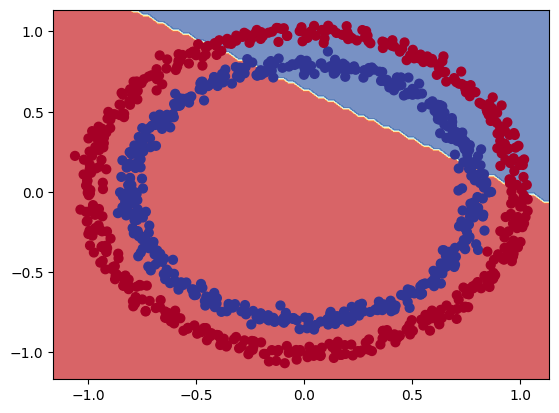

In [ ]:
# Check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

In [ ]:
#Let's see if our model can be used for a regression problem...

tf.random.set_seed(42)

# Create some regression data
X_regression = tf.range(0,1000,5)
y_regression = tf.range(100,1100,5) # y = X+100

X_regression = X_regression.numpy()
y_regression = y_regression.numpy()

# Split our regression data into training & test data
from sklearn.model_selection import train_test_split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_regression,y_regression,test_size= 0.2, random_state=42)

# Fit our model to regression data

#model_3.fit(tf.expand_dims(X_reg_train,axis=-1),tf.expand_dims(y_reg_train,axis=-1),epochs=100,verbose=1)



Oh wait.. we compiled our model for a binary classification problem.

But... we're now working on a regression problem, let's change the model to suit our data.

In [ ]:
# X_reg_train.shape, y_reg_train.shape


In [ ]:
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
# 2. Compile the model, this time with a regression-spesific loss function
model_3.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.Adam(),
                metrics= ["mae"])

# 3. Fit the model
model_3.fit(tf.expand_dims(X_reg_train,axis=-1),tf.expand_dims(y_reg_train,axis=-1),epochs=100,verbose=0)

Şimdi normalde elimizde classification için tanımlı olan bir data vardı. bu datayı belirli değerler arasında oluşturduk ve ne np array'i ne de bir tensöre dönüştürmüştük. Şimdi bu classification için düzenlenen modeli regresyon için kullanırsak ne olur sorusunu sorduk ve hata aldık, çünkü classification için kurduğumuz modelin loss fonksiyonu  BinaryCorssentropy idi yani sınıflandırma loss fonksiyonu, regresyon için kullanılan bir şey değil.

Bu yüzden yine bir model kurmamız gerekti, modeli aynı değişken ismi ile yeniden oluşturduk
ve çalıştırdık bu sefer de tensör olmadıkları için veya np array olmadıkları için(np array olsa da yine hata da alabiliyoruz) bu değişkenlerin şekli itibariyle hata aldık ve burada bu hatayı çözmek için ne yaptık? tf.expand_dims() kullandık. Buradan şunu öğrendik mesele sadece işlem yapılacak tensörlerin shapelerinin eşit olması değilmiş mesele. Çünkü ikisi de ((160,), (160,)) idi. O zaman asıl mesele neymiş? Asıl mesela bunların sonunda bir tane daha değer olması yani bunların 2 boyutlu olmuş olmasıdır. Yoksa bunların hepsini 160 değeri tek değer olarak algılıyor gibi düşün. Bunları teker teker ele alması için bizim tf.expand_dims kullanmamız gerekiyor işte... Bunu kullandığımızda da axis= -1 demeliyiz ki burada durum (160,1) olsun yani 160 tane satır 1 tane sütun.. Bu ne demek bu 160 tane değerin olduğu 160x1'lik bir matris olması demek ve bu matrisin yani 2 boyutlu vektörün üzerinde işlem yapılabilir demek.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


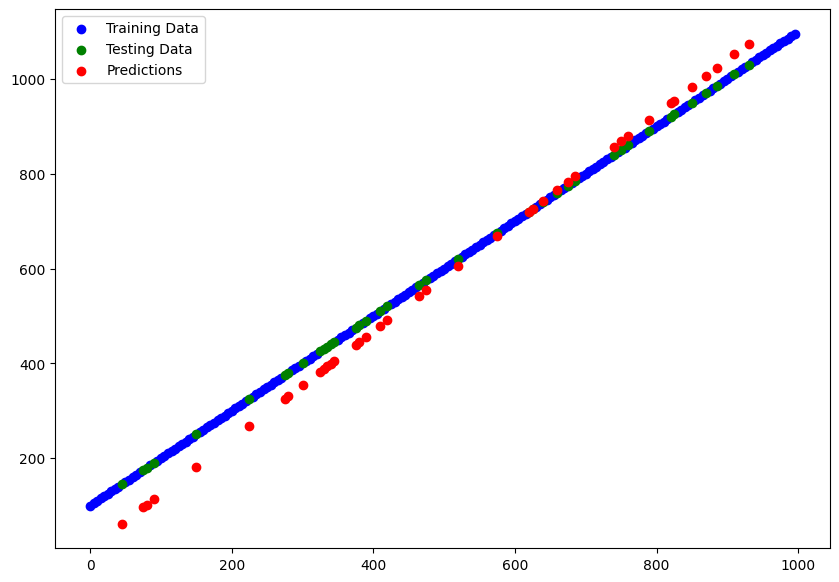

In [ ]:
# Make predictions with our trained model
_reg_preds = model_3.predict(X_reg_test)

# Plot the model's predictions againts our regression data
plt.figure(figsize=(10,7))
plt.scatter(X_reg_train,y_reg_train,c="b",label = "Training Data")
plt.scatter(X_reg_test,y_reg_test,c="g",label = "Testing Data")
plt.scatter(X_reg_test,_reg_preds,c="r",label = "Predictions")
plt.legend()
plt.show()

# The Missing Piece: Non- Linearity

In [ ]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create a model

model_4  =tf.keras.Sequential([
    tf.keras.layers.Dense(1,activation= tf.keras.activations.linear)
]
)

# 2. Compile the model

model_4.compile(loss= tf.keras.losses.BinaryCrossentropy,
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics = ["accuracy"])

# 3. Fit the model

history =model_4.fit(X,tf.expand_dims(y,axis=-1),epochs=100,verbose=0)
history = model_4.history.history


In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

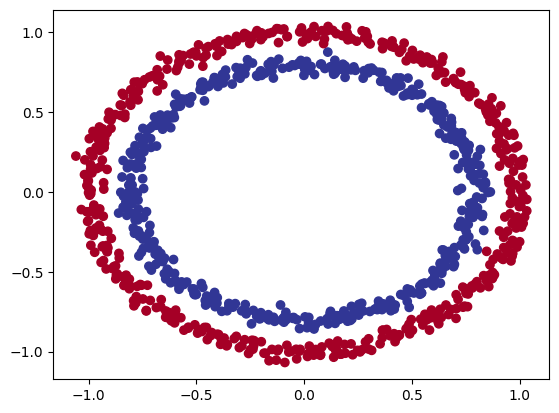

In [ ]:
# Check out our data
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


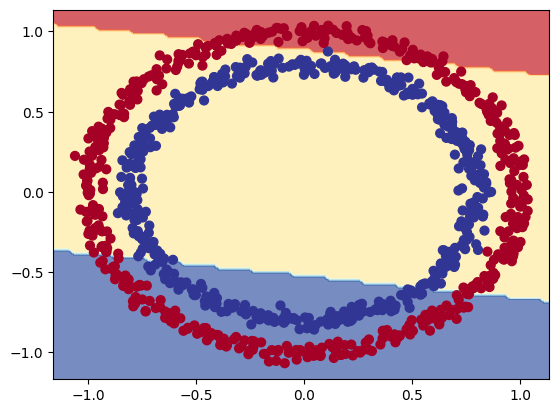

In [ ]:
# Check the desicion boundary for our latest model
plot_decision_boundary(model_4,X,y)

In [ ]:
# Time to replicate the multi-layer neural network from TensorFlow playground
# Set the random seed
tf.random.set_seed(42)

# 1. Create a model

model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")

])

# 2. Compile the model

model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics = ["accuracy"])

# 3. Fit the model

history =model_5.fit(X,tf.expand_dims(y,axis=-1),epochs=100,verbose=0)

In [ ]:
model_5.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9584 - loss: 0.3305


[0.32337647676467896, 0.9700000286102295]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classification


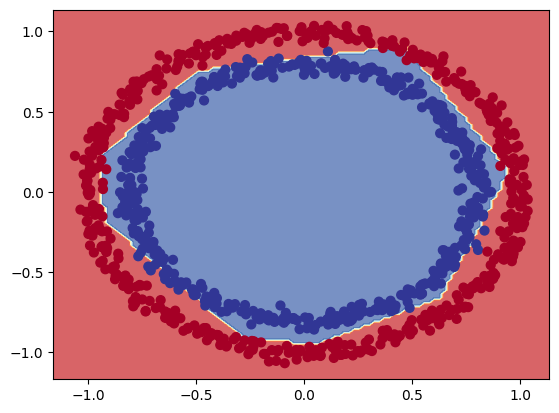

In [ ]:
# How do our model predicsions look?
plot_decision_boundary(model_5,X,y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


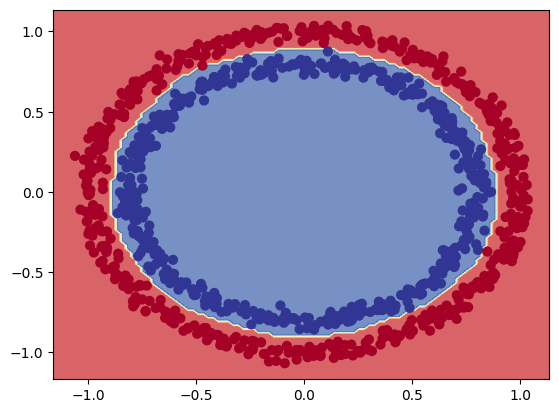

In [ ]:
plot_decision_boundary(model,X,y)

Nice! It looks like our model is almost perfectly (apart from a few examples) separating the two circles.

🤔 Question: What's wrong with the predictions we've made? Are we really evaluating our model correctly here? Hint: what data did the model learn on and what did we predict on?

Before we answer that, it's important to recognize what we've just covered.

🔑 Note: The combination of linear (straight lines) and non-linear (non-straight lines) functions is one of the key fundamentals of neural networks.

Think of it like this:

If I gave you an unlimited amount of straight lines and non-straight lines, what kind of patterns could you draw?

That's essentially what neural networks do to find patterns in data.

Now you might be thinking, "but I haven't seen a linear function or a non-linear function before..."

Oh but you have.

We've been using them the whole time.

They're what power the layers in the models we just built.

To get some intuition about the activation functions we've just used, let's create them and then try them on some toy data.

In [ ]:
# Create a toy a tensor(simular to the data we pass into our models)
A = tf.cast(tf.range(-10,10),tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

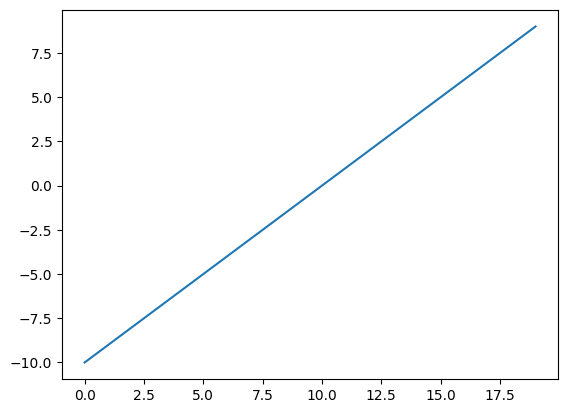

In [ ]:
# Visualize our toy tensor
plt.plot(A)


In [ ]:
# Let's start by replicating sigmoid - sigmoid(x) = 1/(1+exp(-x))

def sigmoid(x):
  return 1/ (1+tf.exp(-x))

# use the sigmoid function on our toy tensor

sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397868e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726230e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105854e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

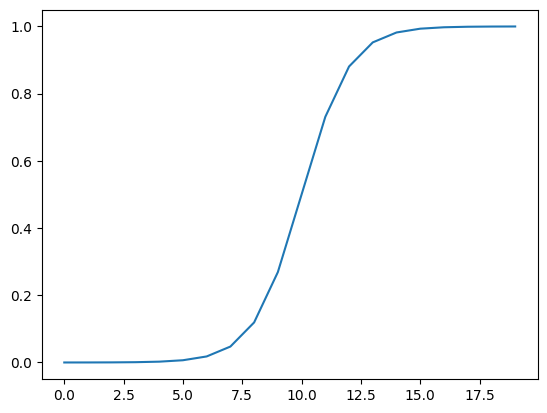

In [ ]:
# Plot our toy tensor transformed by sigmoid
plt.plot(sigmoid(A))

In [ ]:
# Let's recreate the relu function
def relu(x):
  return tf.maximum(0,x)

relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

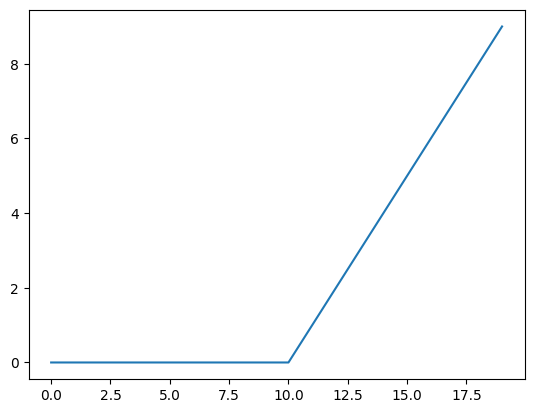

In [ ]:
plt.plot(relu(A))

In [ ]:
# Let's try linear activation function
 #Linear - https://www.tensorflow.org/api_docs/python/tf/keras/activations/linear (returns input non-modified...)
tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

In [ ]:
# Does the linear activation change anything?
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

In [ ]:
len(X)

1000

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(800, 2)

In [ ]:
tf.random.set_seed(42)

# 1. Create the model (same as model_5)
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation= "sigmoid")
])

# 2. Compile the model
model_6.compile(loss= tf.keras.losses.BinaryCrossentropy,
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics= ["accuracy"])

# 3. Fit the model
history = model_6.fit(X_train,tf.expand_dims(y_train,axis=-1),epochs=30,verbose=0)

In [ ]:
model_6.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9944 - loss: 0.0654


[0.06891782581806183, 0.9900000095367432]

In [ ]:
history

In [ ]:
# Evaluate our model on the test set
loss, accuracy = model_6.evaluate(X_test, y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {100*accuracy:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9944 - loss: 0.0654 
Model loss on the test set: 0.06891782581806183
Model accuracy on the test set: 99.00%


95% accuracy? Nice!

Now, when we started to create model_8 we said it was going to be the same as model_7 but you might've found that to be a little lie.

That's because we changed a few things:

The activation parameter - We used strings ("relu" & "sigmoid") instead of using library paths (tf.keras.activations.relu), in TensorFlow, they both offer the same functionality.
The learning_rate (also lr) parameter - We increased the learning rate parameter in the Adam optimizer to 0.01 instead of 0.001 (an increase of 10x).
You can think of the learning rate as how quickly a model learns. The higher the learning rate, the faster the model's capacity to learn, however, there's such a thing as a too high learning rate, where a model tries to learn too fast and doesn't learn anything. We'll see a trick to find the ideal learning rate soon.
The number of epochs - We lowered the number of epochs (using the epochs parameter) from 100 to 25 but our model still got an incredible result on both the training and test sets.
One of the reasons our model performed well in even less epochs (remember a single epoch is the model trying to learn patterns in the data by looking at it once, so 25 epochs means the model gets 25 chances) than before is because we increased the learning rate.
We know our model is performing well based on the evaluation metrics but let's see how it performs visually

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


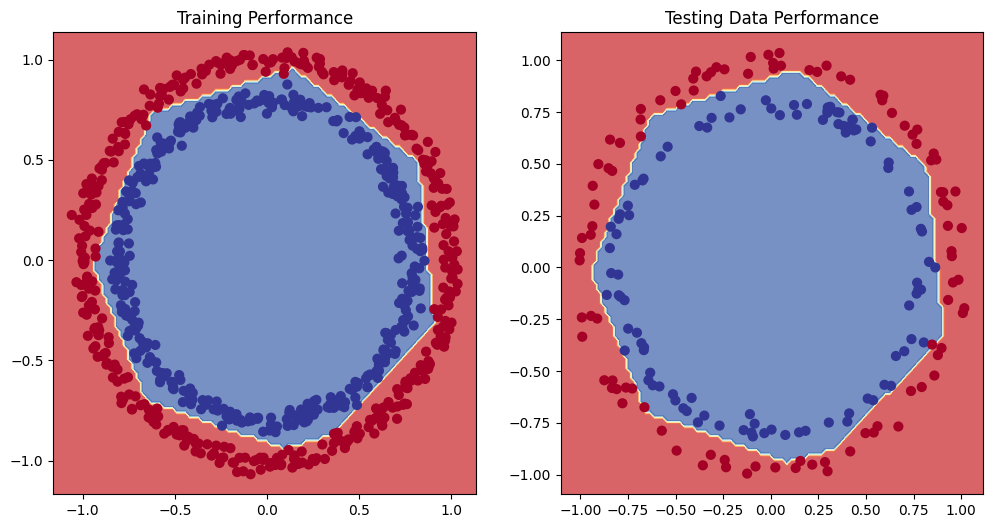

In [ ]:
# Plot the decision boundries for the training and test sets
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Performance")
plot_decision_boundary(model_6,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Testing Data Performance")
plot_decision_boundary(model_6,X_test,y_test)
plt.show()

## Plot the Loss (or training) Curves

In [ ]:
pd.DataFrame(history.history)

,accuracy,loss
0,0.48250,0.693770
1,0.55000,0.687055
2,0.56500,0.680358
3,0.58500,0.670716
4,0.61625,0.655009
5,0.71125,0.626279
6,0.73875,0.588531
7,0.78875,0.543481
8,0.85125,0.487650
9,0.91875,0.420441


Text(0.5, 1.0, 'model_6 loss curves')

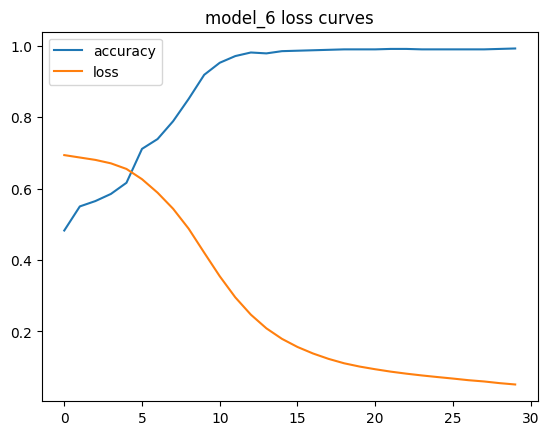

In [ ]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("model_6 loss curves")


🔑 Note: For many problems, the loss function going down means the model is improving (the predictions it's making are getting closer to the ground truth labels)

# Finding the Best Learning Rate

Aside from the architecture itself (the layers, number of neurons, activations, etc), the most important hyperparameter you can tune for your neural network models is the learning rate.

In model_8 you saw we lowered the Adam optimizer's learning rate from the default of 0.001 (default) to 0.01.

And you might be wondering why we did this.

Put it this way, it was a lucky guess.

I just decided to try a lower learning rate and see how the model went.

Now you might be thinking, "Seriously? You can do that?"

And the answer is yes. You can change any of the hyperparamaters of your neural networks.

With practice, you'll start to see what kind of hyperparameters work and what don't.

That's an important thing to understand about machine learning and deep learning in general. It's very experimental. You build a model and evaluate it, build a model and evaluate it.

That being said, I want to introduce you a trick which will help you find the optimal learning rate (at least to begin training with) for your models going forward.

To do so, we're going to use the following:

* A learning rate callback.
  * You can think of a callback as an extra piece of functionality you can add to your model while its training.
* Another model (we could use the same ones as above, we we're practicing building models here).
* A modified loss curves plot.
We'll go through each with code, then explain what's going on.

🔑 Note: The default hyperparameters of many neural network building blocks in TensorFlow are setup in a way which usually work right out of the box (e.g. the Adam optimizer's defaults first, then adjust as needed.

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as model_6)
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation ="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

# Compile the model
model_7.compile(loss= "BinaryCrossentropy",
                optimizer="Adam",
                metrics=["accuracy"])
# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch:1e-4*10**(epoch/20))

# Fit the model (passing lr_scheduler callback)
history_7 = model_7.fit(X_train,y_train,epochs=100,callbacks=[lr_scheduler])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5120 - loss: 0.6963 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5140 - loss: 0.6956 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5189 - loss: 0.6949 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5170 - loss: 0.6941 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5192 - loss: 0.6933 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5310 - loss: 0.6925 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5361 - loss: 0.6917 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5449 - loss: 0.6909 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5392 - loss: 0.6902 - learning_

In [ ]:
#help(tf.keras.callbacks.LearningRateScheduler)

In [ ]:
X_train.shape, y_train.shape

((800, 2), (800,))

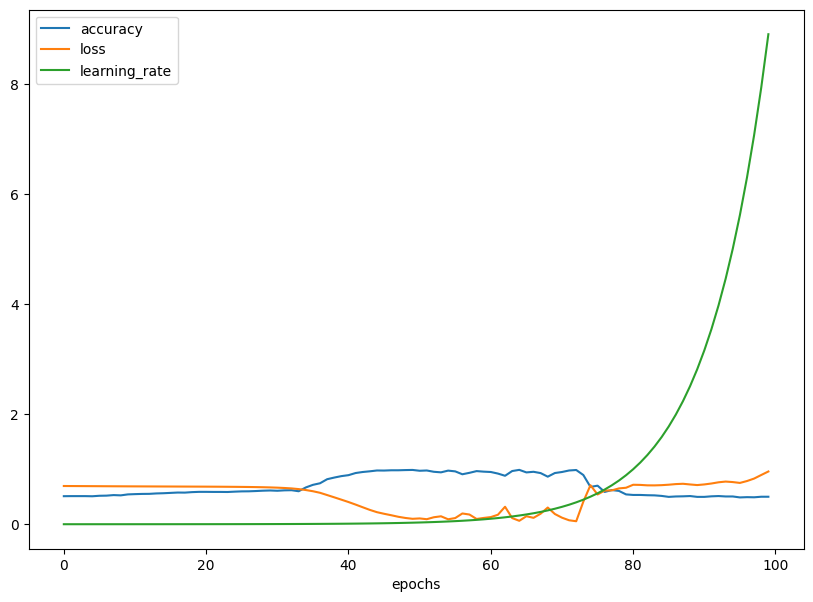

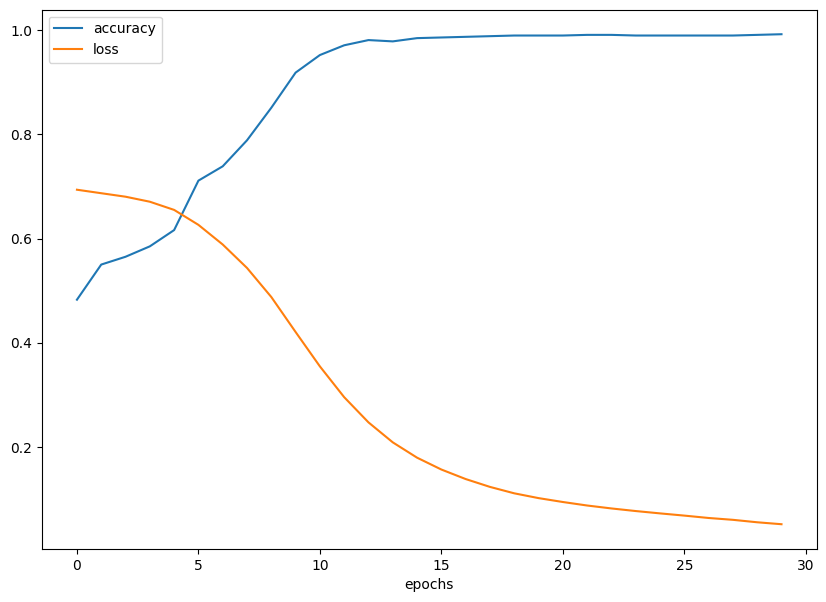

In [ ]:
# Checkout the history
# Learning rate değerlerini her epoch için hesapla
lrs = 1e-4 * (10 ** (np.arange(100)/20))

# history DataFrame'ine ekle
hist_df = pd.DataFrame(history_7.history)
hist_df["learning_rate"] = lrs

# Grafiği çiz
hist_df.plot(figsize=(10,7), xlabel="epochs")

pd.DataFrame(history.history).plot(figsize=(10,7), xlabel="epochs");

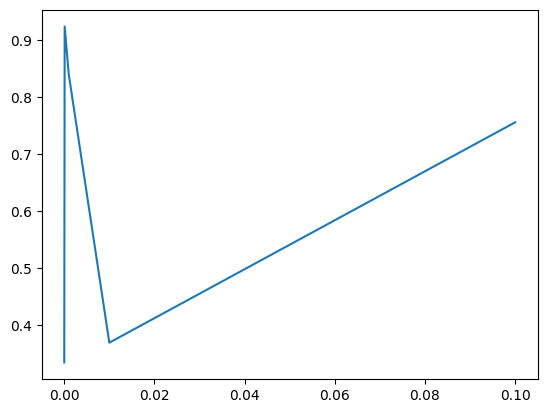

In [ ]:
# Stack overflow araştırması
import numpy as np
import matplotlib.pyplot as plt

# example values
l_rates = np.array([1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
learning_rate_history = np.random.random(size=5)

plt.plot(l_rates, learning_rate_history)
plt.show();

In [ ]:
# Bu learning rate'i daha iyi anlamam için oluşturduğum x^2 x^3 örneği
import numpy as np

def fonk(x):
    x = np.array(x)  # listeyi np.array'e çevir
    return x**3

def fonk2(x):
    x = np.array(x)  # listeyi np.array'e çevir
    return 9*(x**2)

U = [1,2,3,4,5,6,7,8,9]
print(fonk(U))
print(fonk2(U))
int(fonk(2))


[  1   8  27  64 125 216 343 512 729]
[  9  36  81 144 225 324 441 576 729]


8

 Burada aldığımız dersler ne idi? bir fonksiyon tanımlarken fonksiyonun girdi değerini direkt olarak bir dizi vs olarak veremiyorsun ama fonksiyonun içine alınan değeri bir np.array ile dizide dönüştür veya neye ihtiyacın var ise bunu yapabiliyorsun.

 Yani bir fonksiyon yazacağın zaman düşünmen gerekenler:
 * Fonksiyonun amacı
 * Fonksiyonun alacağı değerler
 * Değerlerin hangi veri tipinde ve hangi şekilde geleceği

 Bunları düşündükten sonra gerekli dönüşümleri fonksiyon içinde yapabilirsin.

 **Sonrasında** çıktıyı istediğin formata alabilmek için fonksiyon içine yine hangi formatta almak veya görmek istiyorsan veriyi o formata dönüştürüp ilerleyebilirsin


In [ ]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10**(tf.range(100)/20))
lrs

<tf.Tensor: shape=(100,), dtype=float64, numpy=
array([1.00000000e-04, 1.12201845e-04, 1.25892541e-04, 1.41253754e-04,
       1.58489319e-04, 1.77827941e-04, 1.99526231e-04, 2.23872114e-04,
       2.51188643e-04, 2.81838293e-04, 3.16227766e-04, 3.54813389e-04,
       3.98107171e-04, 4.46683592e-04, 5.01187234e-04, 5.62341325e-04,
       6.30957344e-04, 7.07945784e-04, 7.94328235e-04, 8.91250938e-04,
       1.00000000e-03, 1.12201845e-03, 1.25892541e-03, 1.41253754e-03,
       1.58489319e-03, 1.77827941e-03, 1.99526231e-03, 2.23872114e-03,
       2.51188643e-03, 2.81838293e-03, 3.16227766e-03, 3.54813389e-03,
       3.98107171e-03, 4.46683592e-03, 5.01187234e-03, 5.62341325e-03,
       6.30957344e-03, 7.07945784e-03, 7.94328235e-03, 8.91250938e-03,
       1.00000000e-02, 1.12201845e-02, 1.25892541e-02, 1.41253754e-02,
       1.58489319e-02, 1.77827941e-02, 1.99526231e-02, 2.23872114e-02,
       2.51188643e-02, 2.81838293e-02, 3.16227766e-02, 3.54813389e-02,
       3.98107171e-02, 4.4668

In [ ]:
len(lrs)

100

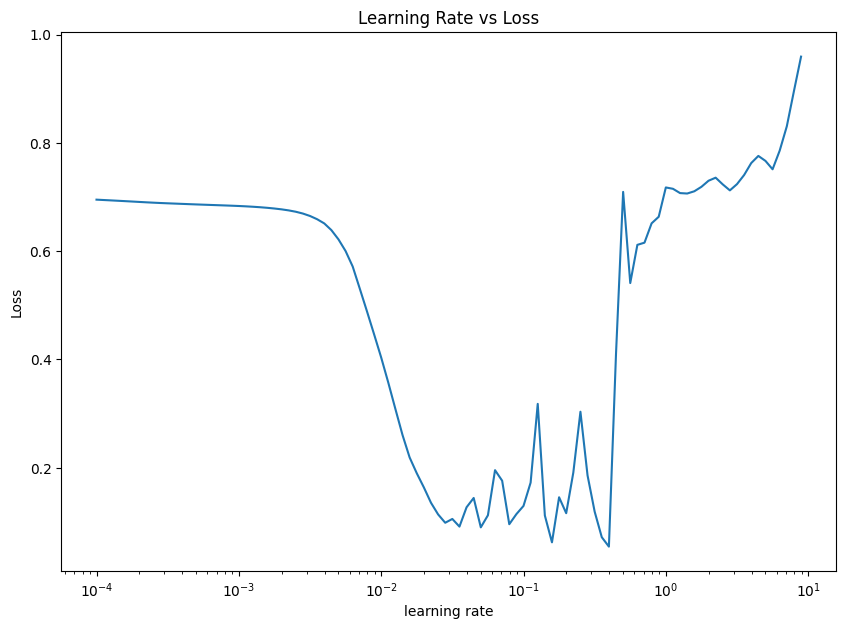

In [ ]:
plt.figure(figsize=(10,7))
plt.semilogx(lrs,history_7.history["loss"])
plt.xlabel("learning rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")
plt.show()

In [ ]:
# Model 8

# 1. Create a model
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation= "relu"),
    tf.keras.layers.Dense(4,activation= "relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

# 2. Compile the model
model_8.compile(loss="BinaryCrossentropy",
                optimizer=tf.keras.optimizers.Adam(0.03),
                metrics=["accuracy"])

# 3. Setting LearningrateScheduler
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch:1e-4*10**(epoch/20))

# 4. Fit the model
history_8 = model_8.fit(X_train,tf.expand_dims(y_train,axis=-1),epochs=100)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4861 - loss: 0.6984
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5698 - loss: 0.6834
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5859 - loss: 0.6611
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7073 - loss: 0.6050
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8232 - loss: 0.4899
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9310 - loss: 0.3212
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9712 - loss: 0.2024
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9866 - loss: 0.1365
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9910 - loss: 0.1050
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9869 - loss: 0.0881
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.0806
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [ ]:
model_8.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9829 - loss: 0.0546


[0.08131500333547592, 0.9750000238418579]

In [ ]:
model_8.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[9.99000490e-01],
       [2.75326427e-03],
       [9.99000490e-01],
       [4.90126349e-02],
       [9.99000490e-01],
       [9.98111367e-01],
       [5.67279176e-06],
       [2.89923889e-07],
       [9.99000490e-01],
       [1.95504806e-04],
       [2.02620804e-01],
       [9.99000490e-01],
       [1.08300323e-04],
       [9.98761892e-01],
       [3.38961817e-02],
       [9.99000490e-01],
       [9.99000490e-01],
       [9.36413471e-06],
       [9.99000490e-01],
       [4.38252613e-02],
       [4.32315064e-05],
       [2.34507542e-08],
       [9.99000490e-01],
       [1.21661301e-07],
       [5.17803244e-04],
       [2.01704025e-01],
       [6.39309201e-06],
       [4.58017737e-03],
       [5.93306027e-08],
       [9.99000490e-01],
       [9.99000490e-01],
       [4.69124061e-04],
       [1.51495501e-01],
       [9.99000490e-01],
       [1.60977637e-04],
       [9.99000490e-01],
       [9.99000490e-01],
       [9.99000490e-01],
       [9.99000490e-01],
       [9.99000490e-01],


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


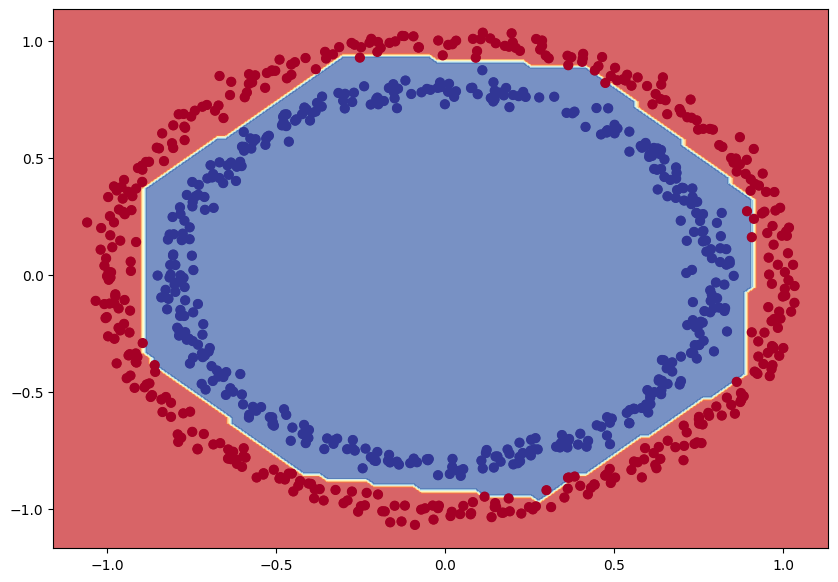

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap=plt.cm.RdYlBu)
plot_decision_boundary(model_8,X_train,y_train)

And as we can see, almost perfect again.

These are the kind of experiments you'll be running often when building your own models.

Start with default settings and see how they perform on your data.

And if they don't perform as well as you'd like, improve them.

Let's look at a few more ways to evaluate our classification models.

# More classification evaluation methods
Alongside the visualizations we've been making, there are a number of different evaluation metrics we can use to evaluate our classification models.

🔑 Note: Every classification problem will require different kinds of evaluation methods. But you should be familiar with at least the ones above.

Let's start with accuracy.

Because we passed ["accuracy"] to the metrics parameter when we compiled our model, calling evaluate() on it will return the loss as well as accuracy.

In [ ]:
# Check the accuracy of our model
loss, accuracy = model_8.evaluate(X_test,y_test)
print(f"Model Loss on the test set:{loss}")
print(f"Model Accuracy on the test set: {(accuracy*100):.2f}%")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.0546 
Model Loss on the test set:0.08131500333547592
Model Accuracy on the test set: 97.50%


### How About a Confusion Matrix ?

In [ ]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

# Make predictions
y_preds = model_8.predict(X_test)

# Create confusion matrix
#confusion matrix = confusion_matrix(y_test,y_preds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [ ]:
y_test[:10]

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [ ]:
y_preds[:10]

array([[9.9900049e-01],
       [2.7532643e-03],
       [9.9900049e-01],
       [4.9012635e-02],
       [9.9900049e-01],
       [9.9811137e-01],
       [5.6727918e-06],
       [2.8992389e-07],
       [9.9900049e-01],
       [1.9550481e-04]], dtype=float32)

Ooops... looks like our predictions array has come out in **prediction probability** form... The standart output from the sigmoid (or softmax)activation functions.

In [ ]:
# Convert prediction probabilities to binary format and view the first 10
tf.round(y_preds)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [ ]:
c_matrix = confusion_matrix(y_test,tf.round(y_preds))
c_matrix

array([[ 95,   5],
       [  0, 100]])

In [ ]:
c_matrix

array([[ 95,   5],
       [  0, 100]])

How About We Prettify Our Confusion Matrix

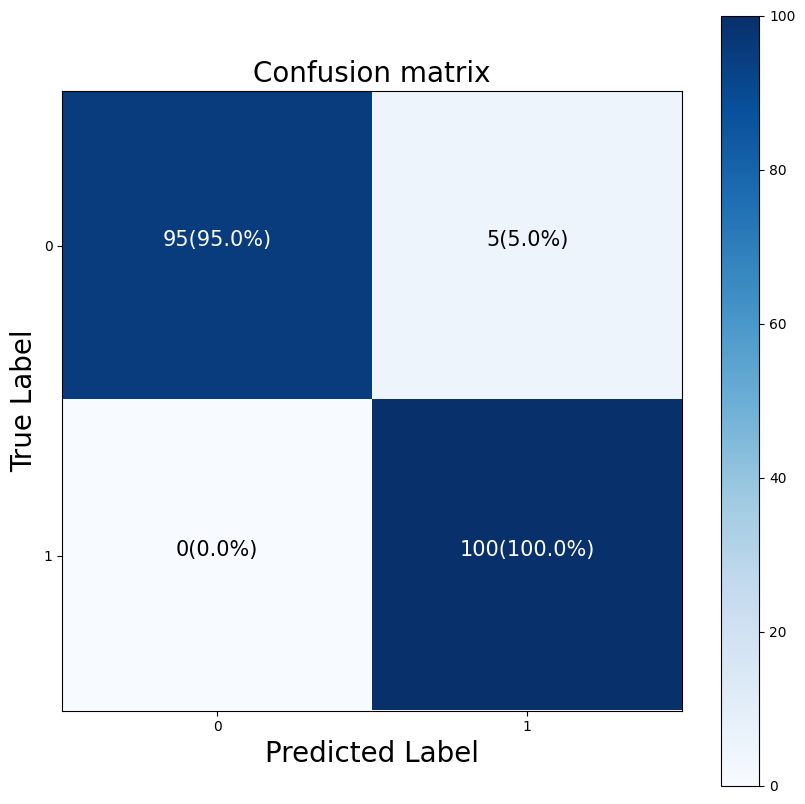

In [ ]:
# Note: The confusion matrix code we're about to write is a remix of scikit-learns plot

import itertools
figsize = (10,10)

# Create the confusion matrix
cm= confusion_matrix(y_test,tf.round(y_preds))
cm_norm = cm.astype("float")/ cm.sum(axis=1) [:,np.newaxis] # normalize our confusion matrix
n_classes = cm.shape[0]

# Lets prettify it
fig, ax = plt.subplots(figsize=figsize)

# Create a matrix plot
cax = ax.matshow(cm,cmap=plt.cm.Blues)
fig.colorbar(cax)

# Create classes
classes = False

if classes:
  labels = classes
else:
  labels= np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion matrix",
         xlabel ="Predicted Label",
         ylabel ="True Label",
         xticks = np.arange(n_classes),
         yticks =np.arange(n_classes),
         xticklabels = labels,
         yticklabels = labels)
# Set x-axis labels to bottom
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

# Adjust label size
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
ax.title.set_size(20)
# Set threshold for different colors
threshold = (cm.max() +cm.min())/2.

# Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
  plt.text(j,i,f"{cm[i,j]}({cm_norm[i,j]*100:.1f}%)",horizontalalignment="center",color="white"if cm[i,j]>threshold else "black",
           size =15)

In [ ]:
n_classes

2

In [ ]:
cm_norm

array([[0.95, 0.05],
       [0.  , 1.  ]])

In [ ]:
#def plot_confusion_matrix(cm,)

In [ ]:
cm.shape[0]

2

In [ ]:
cm.shape[1]

2

In [ ]:
y_preds.shape

(200, 1)

In [ ]:
y_test.shape

(200,)

# Working with a Larger Example (Multiclass Classification)
We've seen a binary classification example (predicting if a data point is part of a red circle or blue circle) but what if you had multiple different classes of things?

For example, say you were a fashion company and you wanted to build a neural network to predict whether a piece of clothing was a shoe, a shirt or a jacket (3 different options).

When you have more than two classes as an option, this is known as multiclass classification.

The good news is, the things we've learned so far (with a few tweaks) can be applied to multiclass classification problems as well.

Let's see it in action.

To start, we'll need some data. The good thing for us is TensorFlow has a multiclass classication dataset known as Fashion MNIST built-in. Meaning we can get started straight away.

We can import it using the tf.keras.datasets module.

📖 Resource: The following multiclass classification problem has been adapted from the TensorFlow classification guide. A good exercise would be to once you've gone through the following example, replicate the TensorFlow guide.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us.
(train_data,train_labels), (test_data,test_labels) = fashion_mnist.load_data()

In [ ]:
# Show the first training exapmle
print(f"Training Sample:\n{train_data[0]}")
print(f"Training Label:\n{train_labels[0]}")

Training Sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [ ]:
# Check the shape of a single example
train_data[0].shape, train_labels[0].shape

((28, 28), ())

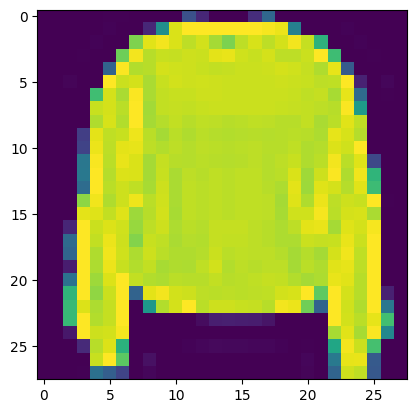

In [ ]:
# Plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[7])

In [ ]:
# Check out samples label
train_labels[7]

np.uint8(2)

In [ ]:
# Create a small list so we can index onto our training labels so they're human-readable
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
len(class_names)

10

Text(0.5, 1.0, 'Coat')

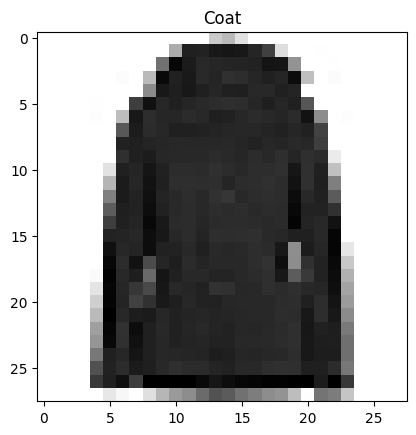

In [ ]:
# Plot an example image and its label
index_of_choice = 2000
plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

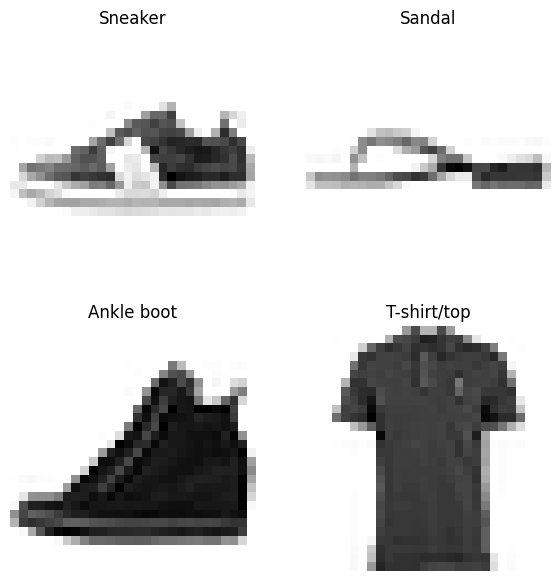

In [ ]:
# Plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7,7))
for i in range(4):
  ax = plt.subplot(2,2,i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index],cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

## Building a Multi-Class Classification Model

Alright, let's build a model to figure out the relationship between the pixel values and their labels.

Since this is a multiclass classification problem, we'll need to make a few changes to our architecture (inline with Table 1 above):

The input shape will have to deal with 28x28 tensors (the height and width of our images).
We're actually going to squash the input into a tensor (vector) of shape (784).
The output shape will have to be 10 because we need our model to predict for 10 different classes.
We'll also change the activation parameter of our output layer to be "softmax" instead of 'sigmoid'. As we'll see the "softmax" activation function outputs a series of values between 0 & 1 (the same shape as output shape, which together add up to ~1. The index with the highest value is predicted by the model to be the most likely class.
We'll need to change our loss function from a binary loss function to a multiclass loss function.
More specifically, since our labels are in integer form, we'll use tf.keras.losses.SparseCategoricalCrossentropy(), if our labels were one-hot encoded (e.g. they looked something like [0, 0, 1, 0, 0...]), we'd use tf.keras.losses.CategoricalCrossentropy().
We'll also use the validation_data parameter when calling the fit() function. This will give us an idea of how the model performs on the test set during training.
You ready? Let's go.

In [ ]:
train_data.shape,train_labels.shape

((60000, 28, 28), (60000,))

In [ ]:
train_labels[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [ ]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model
model_9 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(10,activation="relu"),
    tf.keras.layers.Dense(10,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

# 2. Compile the model
model_9.compile(loss= tf.keras.losses.SparseCategoricalCrossentropy,
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
# 3. Learning Rate Scheduler

lr_scheduler_mc = tf.keras.callbacks.LearningRateScheduler(lambda epoch:1e-4*10**(epoch/20))

# 4. Fit the model
non_norm_history = model_9.fit(train_data,train_labels,epochs=10,callbacks=[lr_scheduler_mc],validation_data=(test_data,test_labels))


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1309 - loss: 10.1206 - val_accuracy: 0.1348 - val_loss: 2.3386 - learning_rate: 1.0000e-04
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1406 - loss: 2.2849 - val_accuracy: 0.1775 - val_loss: 2.2047 - learning_rate: 1.1220e-04
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1834 - loss: 2.1666 - val_accuracy: 0.2029 - val_loss: 2.1123 - learning_rate: 1.2589e-04
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2086 - loss: 2.0820 - val_accuracy: 0.2337 - val_loss: 2.0405 - learning_rate: 1.4125e-04
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2408 - loss: 1.9775 - val_accuracy: 0.2797 - val_loss: 1.9107 - learning_rate: 1.5849e-04
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2914 - loss: 1.8639 - val_accuracy: 0.3250 - val_loss: 1.7961 - learning_rate: 1.7783e-04
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accura

In [ ]:
#Our data needs to be flattened from 28x28 to 784

flatten_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28))
])
flatten_model.output_shape

(None, 784)

In [ ]:
28*28

784

In [ ]:
tf.one_hot(train_labels,depth=10)

<tf.Tensor: shape=(60000, 10), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

In [ ]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(8,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

# 2. Compile the model
model_10.compile(loss= tf.keras.losses.CategoricalCrossentropy,
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
# 3. Learning Rate Scheduler

lr_scheduler_mc = tf.keras.callbacks.LearningRateScheduler(lambda epoch:1e-4*10**(epoch/20))

# 4. Fit the model
non_norm_history = model_10.fit(train_data,tf.one_hot(train_labels,depth=10),epochs=10,callbacks=[lr_scheduler_mc],validation_data=(test_data,tf.one_hot(test_labels,depth=10)))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1109 - loss: 4.5543 - val_accuracy: 0.1203 - val_loss: 2.2607 - learning_rate: 1.0000e-04
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1377 - loss: 2.2267 - val_accuracy: 0.1673 - val_loss: 2.1650 - learning_rate: 1.1220e-04
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1722 - loss: 2.1450 - val_accuracy: 0.1837 - val_loss: 2.1091 - learning_rate: 1.2589e-04
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1975 - loss: 2.0590 - val_accuracy: 0.2644 - val_loss: 1.8792 - learning_rate: 1.4125e-04
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2668 - loss: 1.8398 - val_accuracy: 0.3112 - val_loss: 1.7361 - learning_rate: 1.5849e-04
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3049 - loss: 1.7009 - val_accuracy: 0.3065 - val_loss: 1.6658 - learning_rate: 1.7783e-04
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/ste

In [ ]:
# Check the model summary
model_9.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,212 (94.58 KB)

 Trainable params: 8,070 (31.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,142 (63.06 KB)

In [ ]:
# Check the min and max values of the training data
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

Neural networks prefer data to be slaced (or normalized), this means they like to have the numbers in the tensors they try to find patterns between 0 and 1

In [ ]:
# We can get our training & testing data between 0 and 1 by dividing by maximum
train_data_norm = train_data/255.0
test_data_norm = test_data/255.0

# Check the min and max values of the scaled training data

train_data_norm.min(), train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
# Now our data is normalized, let's build a model to find patterns in it

# Set random seed
tf.random.set_seed(42)

# Create a model (same model as model_9)
model_11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

# Compile the model
model_11.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer= tf.keras.optimizers.Adam(),
                 metrics= ["accuracy"])
# Fit the model

norm_history = model_11.fit(train_data_norm,tf.expand_dims(train_labels,axis=-1),epochs=10, validation_data=(test_data_norm,tf.expand_dims(test_labels,axis=-1)))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3872 - loss: 1.6086 - val_accuracy: 0.6531 - val_loss: 0.9201
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6851 - loss: 0.8361 - val_accuracy: 0.7369 - val_loss: 0.7090
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7501 - loss: 0.6710 - val_accuracy: 0.7533 - val_loss: 0.6597
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7628 - loss: 0.6279 - val_accuracy: 0.7598 - val_loss: 0.6382
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7695 - loss: 0.6059 - val_accuracy: 0.7637 - val_loss: 0.6273
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7733 - loss: 0.5933 - val_accuracy: 0.7650 - val_loss: 0.6196
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7765 - loss: 0.5848 - val_accuracy: 0.7672 - val_loss: 0.6129
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7786 - loss: 0.5785 - 

In [ ]:
tf.__version__

'2.19.0'

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create the model
model_12 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # input layer (we had to reshape 28x28 to 784)
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(10, activation="softmax") # output shape is 10, activation is softmax
])

# Compile the model
model_12.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# Fit the model (to the normalized data)
norm_history = model_12.fit(train_data,
                            train_labels,
                            epochs=10,
                            validation_data=(test_data, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1027 - loss: 2.6554 - val_accuracy: 0.1324 - val_loss: 2.2355
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1295 - loss: 2.2390 - val_accuracy: 0.1640 - val_loss: 2.1320
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1782 - loss: 2.0720 - val_accuracy: 0.2287 - val_loss: 1.7983
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2098 - loss: 1.7994 - val_accuracy: 0.2149 - val_loss: 1.8889
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2252 - loss: 1.7620 - val_accuracy: 0.2746 - val_loss: 1.6892
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2747 - loss: 1.6888 - val_accuracy: 0.2939 - val_loss: 1.6357
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2825 - loss: 1.6548 - val_accuracy: 0.2859 - val_loss: 1.6474
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2827 - loss: 1.6378 - 

Woah, we used the exact same model as before but we with normalized data we're now seeing a much higher accuracy value!

Let's plot each model's history (their loss curves).

In [ ]:
import pandas as pd

# Plot non-normalized data loss curves
pd.DataFrame(non_norm_history.history).plot(title="Non-Normalized Data")
#Plot normalized data loss curves
pd.DataFrame(norm_history.history).plot(title="Normalized Data")

Wow. From these two plots, we can see how much quicker our model with the normalized data (model_12) improved than the model with the non-normalized data (model_11).

🔑 Note: The same model with even slightly different data can produce dramatically different results. So when you're comparing models, it's important to make sure you're comparing them on the same criteria (e.g. same architecture but different data or same data but different architecture).

How about we find the ideal learning rate and see what happens?

We'll use the same architecture we've been using.

## Finding the Ideal Learning Rate

In [ ]:
# Now we are using lr_scheduler

# set random seed
tf.random.set_seed(42)

# 1. Create a model

model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

# 2. Compile the model

model_13.compile(loss= tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(),
                 metrics =["accuracy"])

# 3. Setting a learning rate scheduler callback

lr_scheduler_mc_2 = tf.keras.callbacks.LearningRateScheduler(lambda epoch:1e-3*10**(epoch/20))

# 4. Fit the model

find_lr_history = model_13.fit(train_data_norm,train_labels,epochs=40,validation_data=(test_data_norm,test_labels),callbacks=[lr_scheduler_mc_2 ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3659 - loss: 1.7252 - val_accuracy: 0.7527 - val_loss: 0.7398 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7667 - loss: 0.6879 - val_accuracy: 0.7800 - val_loss: 0.6275 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7864 - loss: 0.6092 - val_accuracy: 0.7894 - val_loss: 0.5964 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7951 - loss: 0.5845 - val_accuracy: 0.7916 - val_loss: 0.5883 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8021 - loss: 0.5703 - val_accuracy: 0.7927 - val_loss: 0.5849 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8065 - loss: 0.5607 - val_accuracy: 0.7924 - val_loss: 0.5825 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8081 - l

Text(0.5, 1.0, 'Finding the ideal learning rate')

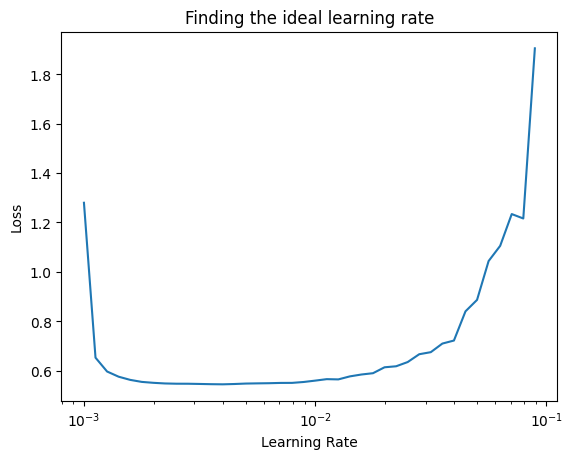

In [ ]:
# Plot the learning rate decay curve
import numpy as np
import matplotlib.pyplot as plt
lrs = 1e-3*10**((tf.range(40)/20))
plt.semilogx(lrs,find_lr_history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate")

In [ ]:
# Let's refit a model with the ideal learning rate

# Set random seed
tf.random.set_seed(42)
# Create model
model_14 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

# Compile the model

model_14.compile(loss= tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                 metrics= ["accuracy"]
                 )

# Fit the model

history_14 = model_14.fit(train_data_norm,train_labels,epochs=40,validation_data=(test_data_norm,test_labels),)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.2914 - loss: 1.7730 - val_accuracy: 0.5363 - val_loss: 1.1702
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6046 - loss: 1.0352 - val_accuracy: 0.7396 - val_loss: 0.7541
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7509 - loss: 0.7264 - val_accuracy: 0.7528 - val_loss: 0.7066
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7699 - loss: 0.6694 - val_accuracy: 0.7833 - val_loss: 0.6389
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7927 - loss: 0.6068 - val_accuracy: 0.7912 - val_loss: 0.6126
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8003 - loss: 0.5801 - val_accuracy: 0.7950 - val_loss: 0.5989
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8044 - loss: 0.5642 - val_accuracy: 0.7989 - val_loss: 0.5898
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8075 - loss: 0.5540 -

## Evaluating our multi-class classification Model

To evaluate our multi-class classification We could:
* Evaluate its performance using other classification metrics (such as confusion matrix)
* Assess some of its predictions (through visualizations)
* Improve its results (by training for longer or changing the architecture)
* Save and export it for use in an application

Let's go through the top 2..



In [ ]:
model_14.evaluate(test_data_norm,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8178 - loss: 0.5303


[0.5412015318870544, 0.8133000135421753]

In [ ]:
 # Create a confusion matrix
import itertools
from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_true,y_preds,classes=None,figsize=(10,10),text_size=15):
  # Create the confusion matrix
  cm = confusion_matrix(y_true,y_preds)
  cm_norm = cm.astype("float")/cm.sum(axis=1)[:,np.newaxis] # normalize our confusion matrix
  n_classes = cm.shape[0]

  # Let's prettify it
  fig, ax = plt.subplots(figsize=figsize)
  # Create a matrix plot
  cax = ax.matshow (cm,cmap =plt.cm.Blues)
  fig.colorbar(cax)

  # Set labels to be classes
  if classes:
    labels= classes
  else:
    labels= np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=text_size)






In [ ]:
# Make some predictions with our model
y_probs = model_14.predict(test_data_norm) # probs is short for prediction probabilities
# View the first 5 predicitons
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[2.4243105e-10, 9.7708655e-29, 3.1528572e-14, 2.9949574e-12,
        2.6967100e-14, 1.8744464e-01, 2.9098095e-11, 6.4084969e-02,
        6.1304774e-05, 7.4840909e-01],
       [2.5136627e-05, 9.3187168e-08, 8.7236029e-01, 7.6150485e-08,
        8.9111008e-02, 4.4124916e-12, 3.8478486e-02, 3.4326602e-30,
        2.4765477e-05, 1.2660288e-20],
       [2.7606653e-03, 9.7139847e-01, 4.8928293e-03, 1.9187531e-02,
        7.6586299e-04, 9.7731936e-05, 8.7968179e-04, 2.8466891e-06,
        1.4085555e-05, 2.9161228e-08],
       [2.9012766e-03, 9.6950567e-01, 5.5420650e-03, 2.0050410e-02,
        8.9584349e-04, 1.0576969e-04, 9.8016509e-04, 2.8277670e-06,
        1.6179674e-05, 3.3649457e-08],
       [1.2268445e-01, 1.1634623e-04, 3.1359550e-01, 9.3634240e-03,
        2.9322259e-02, 2.6624170e-06, 5.2010489e-01, 1.7999457e-16,
        4.8105093e-03, 9.0566448e-15]], dtype=float32)

Since a confusion matrix compares the truth labels (test_labels) to the predicted labels, we have to make some predictions with our model

In [ ]:
# Convert all of the prediction probabilities into integers
y_preds = y_probs.argmax(axis=1)

# View the first 10 prediction labels
y_preds[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [ ]:
# Accuracy
(y_preds==test_labels).sum()/len(test_labels)

np.float64(0.8133)

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
f1_score =f1_score(test_labels,y_preds,average= "weighted")
f1_score

# Sklearn'de bu metrikler için genellikle "average" parametresi gerekir.
# (Özellikle çoklu sınıflandırma için) macro veya weighted kullanabiliriz.
# weighted sınıf dengesizliğini hesaba katar.


0.81212214708713

In [ ]:
recall= recall_score(test_labels,y_preds,average="weighted"),
recall

(0.8133,)

In [ ]:
"""plt.figure(figsize=(10,7))
plt.bar(["Recall","F1 Score"],[recall,f1_score])
plt.title("Recall ve F1 Score Karşılaştırması")
plt.ylabel("Skor Değeri")
plt.show()"""

'plt.figure(figsize=(10,7))\nplt.bar(["Recall","F1 Score"],[recall,f1_score])\nplt.title("Recall ve F1 Score Karşılaştırması")\nplt.ylabel("Skor Değeri")\nplt.show()'

In [ ]:
tf.__version__

'2.19.0'

### Profesyonel Yöntem: Metrik Raporu (Scikit-learn)
Makine öğrenimi projelerinde tahmin performansını sadece doğrulukla değil, Precision, Recall ve F1-Score gibi metriklerle değerlendirmek standart ve daha bilgilendiricidir. sklearn kütüphanesi bu iş için idealdir.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, y_preds))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77      1000
           1       0.92      0.95      0.93      1000
           2       0.70      0.69      0.69      1000
           3       0.79      0.81      0.80      1000
           4       0.68      0.78      0.72      1000
           5       0.91      0.89      0.90      1000
           6       0.59      0.52      0.55      1000
           7       0.88      0.93      0.90      1000
           8       0.95      0.92      0.93      1000
           9       0.92      0.91      0.91      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



In [ ]:
class_names[6] # En çok bunda hata yapıyor model

'Shirt'

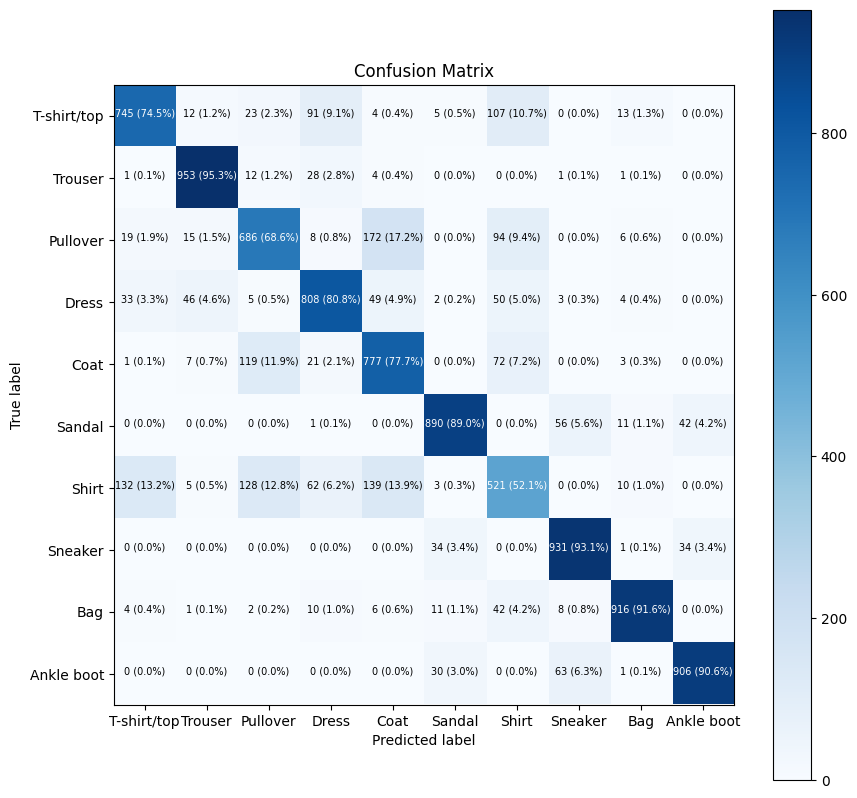

In [ ]:
make_confusion_matrix(y_true=test_labels,y_preds=y_preds,text_size=7,classes=class_names,figsize=(10,10))

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_true=test_labels,y_pred=y_preds)

array([[745,  12,  23,  91,   4,   5, 107,   0,  13,   0],
       [  1, 953,  12,  28,   4,   0,   0,   1,   1,   0],
       [ 19,  15, 686,   8, 172,   0,  94,   0,   6,   0],
       [ 33,  46,   5, 808,  49,   2,  50,   3,   4,   0],
       [  1,   7, 119,  21, 777,   0,  72,   0,   3,   0],
       [  0,   0,   0,   1,   0, 890,   0,  56,  11,  42],
       [132,   5, 128,  62, 139,   3, 521,   0,  10,   0],
       [  0,   0,   0,   0,   0,  34,   0, 931,   1,  34],
       [  4,   1,   2,  10,   6,  11,  42,   8, 916,   0],
       [  0,   0,   0,   0,   0,  30,   0,  63,   1, 906]])

That looks much better! (one of my favourites sights in the world is a confusion matrix with dark squares down the diagonal)

Except the results aren't as good as they could be...

It looks like our model is getting confused between the Shirt and T-shirt/top classes (e.g. predicting Shirt when it's actually a T-shirt/top).

  🤔 Question: Does it make sense that our model is getting confused between the Shirt and T-shirt/top classes? Why do you think this might be? What's one way you could investigate?

We've seen how our models predictions line up to the truth labels using a confusion matrix, but how about we visualize some?

Let's create a function to plot a random image along with its prediction.

  🔑 Note: Often when working with images and other forms of visual data, it's a good idea to visualize as much as possible to develop a further understanding of the data and the outputs of your model.

In [ ]:
import random
def plot_random_image(model,images,true_labels,class_names):
  """ Picks a random image, plots it and labels it with a prediction and true label"""

  # set up random integer
  i = random.randint(0,len(images))

  # Create the predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1,28,28))
  pred_label = class_names[pred_probs.argmax()]
  true_label  =class_names[true_labels[i]]

  # Plot the image
  plt.imshow(target_image,cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label  == true_label:
    color ="green"
  else:
    color="red"

  # Add xlabel information (prediction/ True label)
  plt.xlabel("Pred {}{:2.0f}% (True:{})".format(pred_label,100*tf.reduce_max(pred_probs),true_label),color= color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


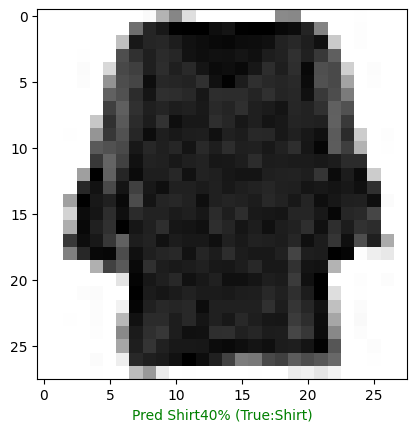

In [ ]:
plot_random_image(model_14,test_data_norm,true_labels=test_labels,class_names=class_names)
# always make predictions on the same kind of data your model was trained on.

In [ ]:
i = random.randint(0,len(test_data_norm))

  # Create the predictions and targets
target_image = test_data_norm[i]
pred_probs = model_14.predict(target_image.reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


## What patterns is our model learning?

In [ ]:
# Find the layers of our most recent model
model_14.layers

[<Flatten name=flatten_13, built=True>,
 <Dense name=dense_73, built=True>,
 <Dense name=dense_74, built=True>,
 <Dense name=dense_75, built=True>]

We've been talking a lot about how a neural network finds patterns in numbers, but what exactly do these patterns look like?

Let's crack open one of our models and find out.

First, we'll get a list of layers in our most recent model (model_14) using the layers attribute.

In [ ]:
# Extract a particular layer
model_14.layers[1]
# We can access a target layer using indexing.


<Dense name=dense_73, built=True>

And we can find the patterns learned by a particular layer using the get_weights() method.

The get_weights() method returns the weights (also known as a weights matrix) and biases (also known as a bias vector) of a particular layer.

In [ ]:
# Get the patterns of a layer in our network
weights, biases = model_14.layers[1].get_weights()

# Shape = 1 weight matrix the size of our input data (28x28) per neuron (4)
weights, weights.shape

(array([[-0.5641326 ,  0.324815  ,  0.7789866 , -0.46627837],
        [ 1.3213812 , -0.44212133, -1.8651704 , -0.51897556],
        [ 1.7934606 , -1.9311857 , -1.0396127 , -1.4683573 ],
        ...,
        [ 0.532072  , -0.238497  , -0.17349705,  0.94645333],
        [-0.71623033,  0.33155945, -0.5986956 ,  1.6905313 ],
        [ 0.4686322 , -0.3723463 , -0.36985034,  0.57026243]],
       dtype=float32),
 (784, 4))

The weights matrix is the same shape as the input data, which in our case is 784 (28x28 pixels). And there's a copy of the weights matrix for each neuron the in the selected layer (our selected layer has 4 neurons).

Each value in the weights matrix corresponds to how a particular value in the input data influences the network's decisions.

These values start out as random numbers (they're set by the kernel_initializer parameter when creating a layer, the default is "glorot_uniform") and are then updated to better representative values of the data (non-random) by the neural network during training.

Example workflow of how a supervised neural network starts with random weights and updates them to better represent the data by looking at examples of ideal outputs.

Now let's check out the bias vector.

In [ ]:
# Shape = 1 bias per neuron (we use 4 neurons in the first layer)
biases, biases.shape

(array([2.311789 , 3.6029675, 2.6840725, 1.4028296], dtype=float32), (4,))

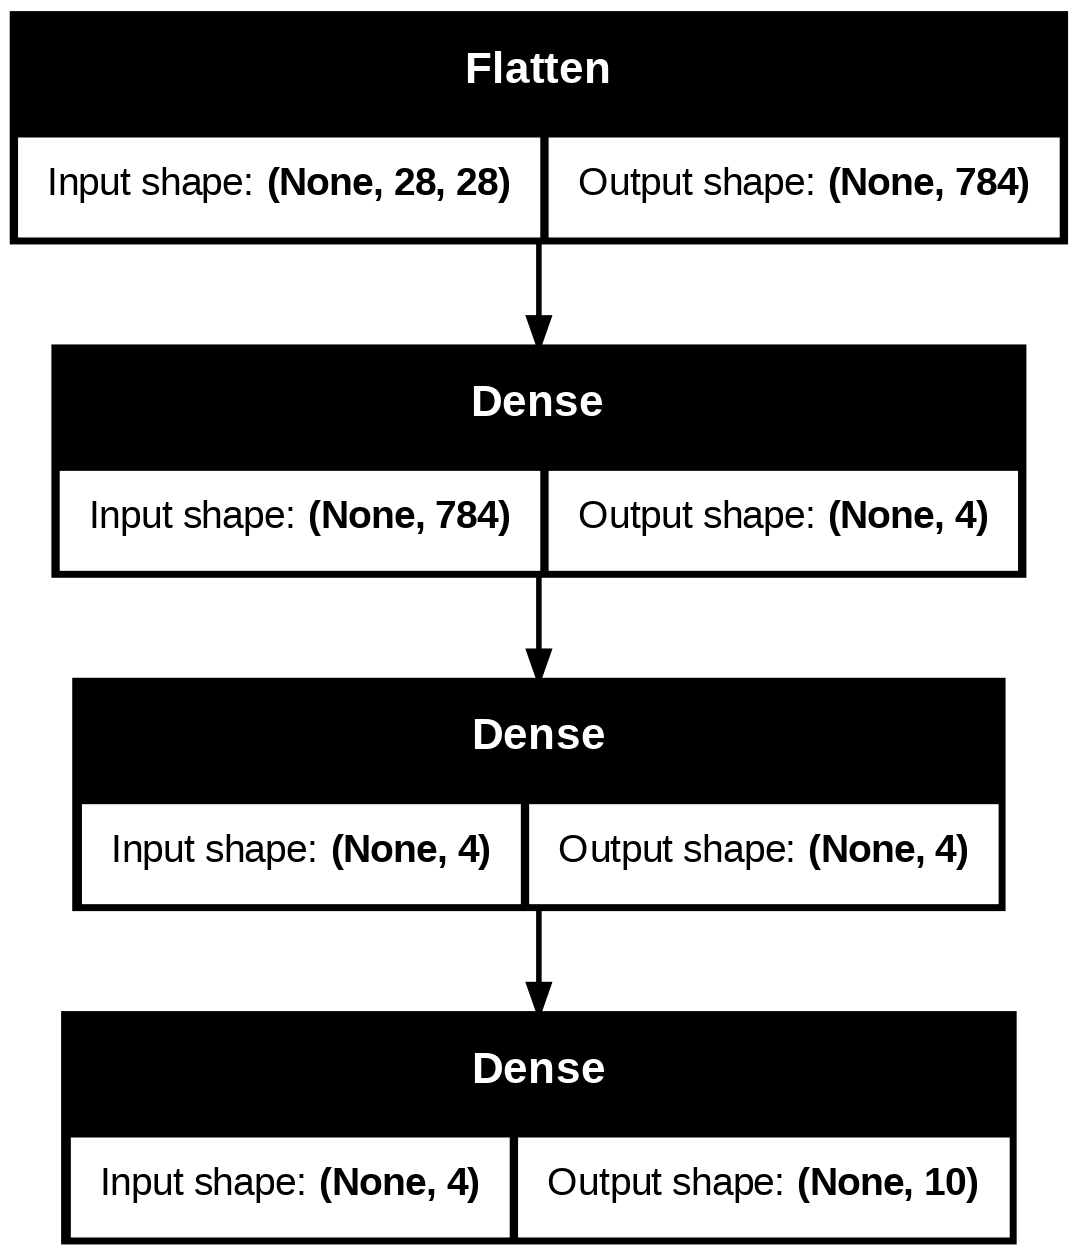

In [ ]:
# Let's check out another way of viewing our deep learning models
from tensorflow.keras.utils import plot_model

# See the inputs and outputs of each layer
plot_model(model_14,show_shapes=True)


# How a model learns (in brief)
Alright, we've trained a bunch of models, but we've never really discussed what's going on under the hood. So how exactly does a model learn?

A model learns by updating and improving its weight matrices and biases values every epoch (in our case, when we call the fit() fucntion).

It does so by comparing the patterns its learned between the data and labels to the actual labels.

If the current patterns (weight matrices and bias values) don't result in a desirable decrease in the loss function (higher loss means worse predictions), the optimizer tries to steer the model to update its patterns in the right way (using the real labels as a reference).

This process of using the real labels as a reference to improve the model's predictions is called backpropagation.

In other words, data and labels pass through a model (forward pass) and it attempts to learn the relationship between the data and labels.

And if this learned relationship isn't close to the actual relationship or it could be improved, the model does so by going back through itself (backward pass) and tweaking its weights matrices and bias values to better represent the data.

If all of this sounds confusing (and it's fine if it does, the above is a very succinct description), check out the resources in the extra-curriculum section for more.

# Exercises 🛠
Play with neural networks in the TensorFlow Playground for 10-minutes. Especially try different values of the learning, what happens when you decrease it? What happens when you increase it?
Replicate the model pictured in the TensorFlow Playground diagram below using TensorFlow code. Compile it using the Adam optimizer, binary crossentropy loss and accuracy metric. Once it's compiled check a summary of the model.